# 02. Modeling Experiments

Этот ноутбук — главный narrative-артефакт проекта по рекомендациям банковских продуктов. Он последовательно показывает:

- как бизнес-задача переводится в ranking-постановку;
- как формируется target «новый продукт в следующем месяце»;
- почему используется time-based split;
- как устроены baseline, feature engineering и основная CatBoost-модель;
- как организован компактный и воспроизводимый этап подбора конфигурации;
- как по `val_map_at_3` выбирается финальная конфигурация и итоговая модель.


## 1. Бизнес-задача и ML-постановка

Банку недостаточно предсказать текущий продуктовый портфель клиента. Практическая задача другая: предложить **новый** продукт, который клиент с высокой вероятностью подключит в ближайшем будущем.

В проекте это оформлено как **multilabel recommendation / ranking**:

- на входе есть клиентский снимок в месяце `t`;
- target — продукты, которые появились в месяце `t+1`, но отсутствовали в `t`;
- уже имеющиеся продукты исключаются из списка рекомендаций;
- модель оценивается не по `accuracy`, а по качеству top-k списка.

Главная метрика проекта и MLflow-run'ов: **`val_map_at_3`**. Она учитывает и попадание продукта в рекомендации, и его позицию в топ-3.

In [2]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.build_dataset import load_modeling_month
from src.data.constants import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, PRODUCT_COLUMNS, PRODUCT_NAME_MAP
from src.models.evaluate import build_recommendation_indices
from src.models.predict import score_dataframe
from src.models.train import ENGINEERED_NUMERIC_FEATURES, build_split_summary_frame, load_sampled_evaluation_frames, run_training
from src.utils.config import ProjectConfig

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

config = ProjectConfig()
MODELS_DIR = PROJECT_ROOT / 'models'

experiment_setup = pd.DataFrame(
    {
        'parameter': ['Primary metric', 'Top-k', 'Train months', 'Validation months', 'Test months'],
        'value': [config.primary_metric_name, config.top_k, len(config.train_months), len(config.valid_months), len(config.test_months)],
    }
)
experiment_setup


,parameter,value
0,Primary metric,val_map_at_3
1,Top-k,3
2,Train months,10
3,Validation months,3
4,Test months,2


## 2. Почему это не обычная классификация по строкам

Случайный `train_test_split` здесь был бы ошибкой по двум причинам.

1. Он смешивает прошлое и будущее, а значит создаёт утечку.
2. Он подменяет задачу: вместо предсказания **новых подключений** модель начинает угадывать уже имеющийся портфель.

Ниже показан реальный объект моделирования: клиент в месяце `t`, его текущие продукты и target-продукты, появившиеся только в `t+1`.

In [3]:
sample_month = load_modeling_month(config, config.valid_months[0])
positive_example = sample_month.loc[sample_month['target_count'] > 0].head(1).copy()

current_products = [product for product in PRODUCT_COLUMNS if int(positive_example.iloc[0][product]) == 1]
new_products = [product for product in PRODUCT_COLUMNS if int(positive_example.iloc[0][f'target__{product}']) == 1]

pd.DataFrame(
    {
        'snapshot_month': [str(positive_example.iloc[0]['fecha_dato'].date())],
        'target_month': [str(positive_example.iloc[0]['target_month'].date())],
        'customer_id': [int(positive_example.iloc[0]['ncodpers'])],
        'current_products': [', '.join(current_products[:8]) + (' ...' if len(current_products) > 8 else '')],
        'new_products_next_month': [', '.join(new_products)],
        'target_count': [int(positive_example.iloc[0]['target_count'])],
    }
)

,snapshot_month,target_month,customer_id,current_products,new_products_next_month,target_count
0,2015-12-28,2016-01-28,1017829,"ind_cco_fin_ult1, ind_ecue_fin_ult1",ind_dela_fin_ult1,1


В этой таблице видно, что объектом моделирования является не сам клиентский снимок, а переход между двумя соседними месяцами. Текущие продукты фиксируют состояние клиента в момент `t`, а `new_products_next_month` показывает именно те подключения, которые появились в `t+1`. Такой формат делает задачу рекомендационной, а не просто классификационной.


## 3. Time-based split

В проекте используется только временное разделение на выборки.

- `train`: исторические месяцы, на которых модель обучается;
- `validation`: фиксированный период для отбора конфигураций и сравнения stage-run'ов;
- `test`: финальный holdout для проверки, что выигрыш не остался только на validation.

Такой split соответствует реальной эксплуатации: банк всегда обучается на прошлом и принимает решение на будущем месяце.

In [4]:
split_periods = pd.DataFrame(
    {
        'split': ['train', 'validation', 'test'],
        'months': [
            ', '.join(config.train_months),
            ', '.join(config.valid_months),
            ', '.join(config.test_months),
        ],
        'months_count': [len(config.train_months), len(config.valid_months), len(config.test_months)],
    }
)
split_periods

,split,months,months_count
0,train,"2015-02-28, 2015-03-28, 2015-04-28, 2015-05-28, 2015-06-28, 2015-07-28, 2015-08-28, 2015-09-28, 2015-10-28, 2015-11-28",10
1,validation,"2015-12-28, 2016-01-28, 2016-02-28",3
2,test,"2016-03-28, 2016-04-28",2


Эта таблица задаёт хронологию эксперимента. Из неё видно, что обучение, валидация и тест идут строго по времени и не пересекаются. Такая схема исключает утечку будущего и сохраняет реалистичный сценарий: модель обучается на прошлом и применяется к более поздним месяцам.


In [5]:
split_summary_path = MODELS_DIR / 'split_summary.csv'
if split_summary_path.exists():
    split_summary = pd.read_csv(split_summary_path)
else:
    split_summary = build_split_summary_frame(config)

split_overview = (
    split_summary.groupby('split', as_index=False)
    .agg(
        months=('snapshot_month', 'nunique'),
        rows=('rows', 'sum'),
        unique_clients=('unique_clients', 'sum'),
        rows_with_target=('rows_with_target', 'sum'),
        target_events=('target_events', 'sum'),
        positive_rate=('positive_rate', 'mean'),
    )
)

monthly_split_table = split_summary.copy()
monthly_split_table

,split,snapshot_month,rows,unique_clients,rows_with_target,target_events,positive_rate
0,train,2015-02-28,627394,627394,25197,31948,0.0402
1,train,2015-03-28,629209,629209,25496,30427,0.0405
2,train,2015-04-28,630367,630367,21203,26311,0.0336
3,train,2015-05-28,631957,631957,33318,41745,0.0527
4,train,2015-06-28,632110,632110,26097,33362,0.0413
5,train,2015-07-28,829817,829817,24326,29490,0.0293
6,train,2015-08-28,843201,843201,28479,35696,0.0338
7,train,2015-09-28,865440,865440,32208,39803,0.0372
8,train,2015-10-28,892251,892251,28036,35215,0.0314
9,train,2015-11-28,906109,906109,33684,42353,0.0372


Помесячная сводка показывает не только границы split, но и масштаб данных внутри каждого периода. В train-периоде объём растёт от `627,394` строк в феврале 2015 до `906,109` строк в ноябре 2015. На validation используются три месяца с суммарно `2,749,194` строками, а на test — два месяца и `1,853,350` строк. Positive-события остаются редкими во всех частях эксперимента: доля строк хотя бы с одним новым продуктом лежит примерно в диапазоне `2.9%`–`5.3%`.


Сводка фиксирует два свойства задачи.

- positive-события редки: в train `278,044` строк с target и `346,350` продуктовых событий, в validation `90,074` и `115,183`, в test `54,611` и `68,805`;
- validation и test сохраняют временную структуру, поэтому метрики отражают сценарий реального применения, а не случайное перемешивание строк.


In [6]:
split_overview

,split,months,rows,unique_clients,rows_with_target,target_events,positive_rate
0,test,2,1853350,1853350,54611,68805,0.0295
1,train,10,7487855,7487855,278044,346350,0.0377
2,validation,3,2749194,2749194,90074,115183,0.0328


Агрегированная сводка по split подтверждает дисбаланс задачи. В train положительная доля составляет `3.77%`, в validation `3.28%`, в test `2.95%`. При таком устройстве данных ranking-метрики действительно информативнее обычной accuracy: модель должна правильно расставить несколько релевантных продуктов среди большого числа нерелевантных кандидатов.


## 4. Как формируется рекомендация

На этапе inference модель выдаёт score для всех продуктов. Но рекомендовать можно только те продукты, которых у клиента ещё нет.

Поэтому ranking устроен так:

1. считаются score по всем 24 продуктам;
2. уже имеющиеся продукты маскируются;
3. берётся top-`k` по оставшимся score.

Ниже показан мини-пример с маскированием уже имеющихся продуктов.

In [7]:
example_scores = np.array([[0.91, 0.72, 0.34, 0.67, 0.12]])
example_current_products = np.array([[1, 0, 0, 1, 0]])
example_recommendations = build_recommendation_indices(example_scores, example_current_products, k=3)

pd.DataFrame(
    {
        'raw_scores': [example_scores.tolist()[0]],
        'current_product_mask': [example_current_products.tolist()[0]],
        'top3_after_masking': [example_recommendations.tolist()[0]],
    }
)

,raw_scores,current_product_mask,top3_after_masking
0,"[0.91, 0.72, 0.34, 0.67, 0.12]","[1, 0, 0, 1, 0]","[1, 2, 4]"


Этот пример иллюстрирует ключевое правило inference. Даже если уже имеющийся продукт получает высокий raw score, он не должен попадать в финальную выдачу. После маскирования top-3 формируется только из тех продуктов, которых у клиента ещё нет, и именно это превращает score-модель в полноценный recommendation pipeline.


## 5. Базовые уровни и feature engineering

Экспериментальная лестница начинается с двух baseline'ов:

- `global_popularity`: рекомендует самые частые новые подключения по всей базе;
- `segment_popularity`: делает то же самое, но с сегментацией по `segmento`.

После baseline'ов проект переходит к CatBoost. Для неё добавлены признаки, которые описывают недавнюю динамику клиента:

- номер месяца;
- стаж клиента в месяцах;
- размер текущего портфеля;
- размер портфеля в прошлом месяце;
- число недавно добавленных и потерянных продуктов;
- бинарный признак недавнего появления нового продукта.


In [8]:
feature_groups = pd.DataFrame(
    {
        'feature_group': ['Raw numeric', 'Categorical', 'Current portfolio', 'Engineered temporal / delta'],
        'feature_count': [len(NUMERIC_COLUMNS), len(CATEGORICAL_COLUMNS), len(PRODUCT_COLUMNS), len(ENGINEERED_NUMERIC_FEATURES)],
        'examples': [
            ', '.join(NUMERIC_COLUMNS[:5]),
            ', '.join(CATEGORICAL_COLUMNS[:5]),
            ', '.join(PRODUCT_COLUMNS[:4]),
            ', '.join(ENGINEERED_NUMERIC_FEATURES),
        ],
    }
)
feature_groups

,feature_group,feature_count,examples
0,Raw numeric,8,"age, ind_nuevo, antiguedad, indrel, tipodom"
1,Categorical,12,"ind_empleado, pais_residencia, sexo, indrel_1mes, tiprel_1mes"
2,Current portfolio,24,"ind_ahor_fin_ult1, ind_aval_fin_ult1, ind_cco_fin_ult1, ind_cder_fin_ult1"
3,Engineered temporal / delta,7,"month_number, customer_since_months, prev_products_total, products_total, products_added_prev_month, products_droppe..."


Таблица с группами признаков показывает, что модель использует четыре слоя сигналов: `8` raw numeric-признаков, `12` категориальных, `24` индикатора текущего портфеля и `7` engineered temporal / delta-признаков. В сумме это объясняет, почему feature engineering здесь полезен: модель видит не только профиль клиента, но и динамику его продуктового поведения между месяцами.


## 6. Почему основная модель — CatBoost

CatBoost здесь уместен по практическим причинам:

- в данных много категориальных полей;
- есть пропуски и шум в клиентских атрибутах;
- между сегментом, каналом, активностью, доходом и текущим портфелем есть нелинейные связи;
- нежелательно раздувать пространство признаков ручным one-hot кодированием.

Поэтому проект использует CatBoost как основную табличную модель, а baseline и feature engineering нужны для прозрачного сравнения этапов, а не как изолированные эксперименты.


## 7. Компактная tuning-stage

В проекте используется контролируемый отбор конфигураций вместо широкого brute-force поиска. Логика intentionally простая и воспроизводимая.

### Stage A. Быстрый screening

- берётся небольшой ручной набор разумных конфигураций CatBoost;
- обучение идёт на части train-периода;
- validation остаётся строго time-based;
- каждая конфигурация логируется как отдельный run в MLflow.

### Stage B. Финальное подтверждение

- в работу идут только top-N конфигураций из Stage A;
- они переобучаются на полном train sample;
- сравнение снова идёт по `val_map_at_3`;
- победившая конфигурация становится финальной tuned-моделью и затем регистрируется в MLflow Model Registry.

Такая схема делает этап подбора прозрачным, достаточно дешёвым и удобным для ревью.


In [9]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    bundle = run_training(config)
    selected_stage = bundle['selected_model']
else:
    metadata_path = MODELS_DIR / 'model_metadata.json'
    if not metadata_path.exists():
        raise FileNotFoundError('Сначала нужно запустить обучение: bash scripts/train_model.sh')
    selected_stage = json.loads(metadata_path.read_text(encoding='utf-8'))['selected_model']

selected_stage

'stage_04_catboost_tuned'

In [10]:
metadata = json.loads((MODELS_DIR / 'model_metadata.json').read_text(encoding='utf-8'))
experiment_leaderboard = pd.read_csv(MODELS_DIR / 'experiment_leaderboard.csv')
stage_a_leaderboard = pd.read_csv(MODELS_DIR / 'stage_04_stage_a_leaderboard.csv') if (MODELS_DIR / 'stage_04_stage_a_leaderboard.csv').exists() else pd.DataFrame()
stage_b_leaderboard = pd.read_csv(MODELS_DIR / 'stage_04_stage_b_leaderboard.csv') if (MODELS_DIR / 'stage_04_stage_b_leaderboard.csv').exists() else pd.DataFrame()
tuning_summary = json.loads((MODELS_DIR / 'stage_04_tuning_summary.json').read_text(encoding='utf-8')) if (MODELS_DIR / 'stage_04_tuning_summary.json').exists() else {}

experiment_leaderboard


,stage_name,model_name,val_map_at_3,val_precision_at_3,val_recall_at_3,val_ndcg_at_3,test_map_at_3,test_precision_at_3,test_recall_at_3,test_ndcg_at_3,run_id,notes
0,stage_04_catboost_tuned,catboost_tuned,0.6641,0.0809,0.7640,0.6948,0.6527,0.0701,0.7543,0.6841,84f4cd55105a4ca8a669a5bc224fd6fc,"Two-stage CatBoost tuning: Stage A screens a compact manual candidate set on recent train months, Stage B confirms o..."
1,stage_03_catboost_feature_engineering,catboost_feature_engineering,0.6586,0.0803,0.7592,0.6896,0.6505,0.0701,0.7552,0.6827,b557a26092754a598789a25bf7798c9c,"CatBoost after temporal and portfolio-delta feature engineering, still using time-based eval_set and early stopping."
2,stage_02_catboost_basic,catboost_basic,0.6302,0.0777,0.7360,0.6628,0.6211,0.0680,0.7259,0.6535,323652f845d6493e994c81580a7cace2,CatBoost on raw profile and current products with a fixed validation eval_set and early stopping.
3,stage_01_segment_popularity,segment_popularity,0.6215,0.0796,0.7403,0.6592,0.6180,0.0701,0.7324,0.6546,cece15fad4ac4160a5552217088fbaf9,Segment-smoothed popularity baseline by `segmento`.
4,stage_00_global_popularity,global_popularity,0.5849,0.0789,0.7755,0.6502,0.5753,0.0704,0.7714,0.6415,df6dbedcd34f48aa8581b8ba0dc6b313,Global popularity baseline for new product adoption.


Эта таблица собирает в одном месте все stage-run'ы и уже по текущему прогону показывает понятный порядок сил. Лучшей стала `stage_04_catboost_tuned` с `val_map_at_3 = 0.6641` и `test_map_at_3 = 0.6527`. За ней идёт `stage_03_catboost_feature_engineering` (`0.6586` / `0.6505`), затем `stage_02_catboost_basic` (`0.6302` / `0.6211`). Оба baseline заметно слабее по основной метрике.


In [11]:
best_bundle = joblib.load(MODELS_DIR / 'best_model.joblib')
stage_tracking = pd.DataFrame(
    {
        'signal': ['selected_stage', 'primary_metric_name', 'registered_model_name', 'registered_model_alias', 'stage_a_candidates', 'stage_b_top_n'],
        'value': [
            best_bundle.get('selected_model'),
            best_bundle.get('primary_metric_name'),
            metadata.get('registered_model_name'),
            metadata.get('registered_model_alias'),
            tuning_summary.get('stage_a_candidate_count'),
            tuning_summary.get('stage_b_top_n'),
        ],
    }
)
stage_tracking


,signal,value
0,selected_stage,stage_04_catboost_tuned
1,primary_metric_name,val_map_at_3
2,registered_model_name,bank-product-recommendations-catboost
3,registered_model_alias,champion
4,stage_a_candidates,4
5,stage_b_top_n,2


Эта таблица собирает в одном месте все stage-run'ы и служит основой для дальнейшего сравнения. Она связывает narrative ноутбука с артефактами пайплайна: именно эти результаты записываются в `model_metadata.json`, сохраняются в `experiment_leaderboard.csv` и логируются в MLflow.


## 8. Сравнение baseline vs CatBoost vs tuned CatBoost

Таблица ниже показывает не набор разрозненных запусков, а **лестницу улучшений**:

- сначала берётся честная популярностная точка отсчёта;
- затем проверяется сегментированный baseline;
- затем измеряется эффект перехода к CatBoost;
- потом оценивается вклад feature engineering;
- в конце проверяется, даёт ли дополнительный выигрыш tuning-stage.


In [12]:
comparison_columns = [
    'stage_name',
    'model_name',
    'val_map_at_3',
    'val_precision_at_3',
    'val_recall_at_3',
    'val_ndcg_at_3',
    'test_map_at_3',
]
experiment_leaderboard[comparison_columns]

,stage_name,model_name,val_map_at_3,val_precision_at_3,val_recall_at_3,val_ndcg_at_3,test_map_at_3
0,stage_04_catboost_tuned,catboost_tuned,0.6641,0.0809,0.7640,0.6948,0.6527
1,stage_03_catboost_feature_engineering,catboost_feature_engineering,0.6586,0.0803,0.7592,0.6896,0.6505
2,stage_02_catboost_basic,catboost_basic,0.6302,0.0777,0.7360,0.6628,0.6211
3,stage_01_segment_popularity,segment_popularity,0.6215,0.0796,0.7403,0.6592,0.6180
4,stage_00_global_popularity,global_popularity,0.5849,0.0789,0.7755,0.6502,0.5753


Сравнительная таблица показывает, что tuning действительно дал измеримый выигрыш. Финальная tuned-модель улучшила validation `MAP@3` на `+0.0054` относительно `stage_03_catboost_feature_engineering`, на `+0.0339` относительно `stage_02_catboost_basic` и на `+0.0791` относительно глобального popularity baseline. На test лидерство тоже сохранилось: `0.6527` против `0.6505` у `stage_03`.


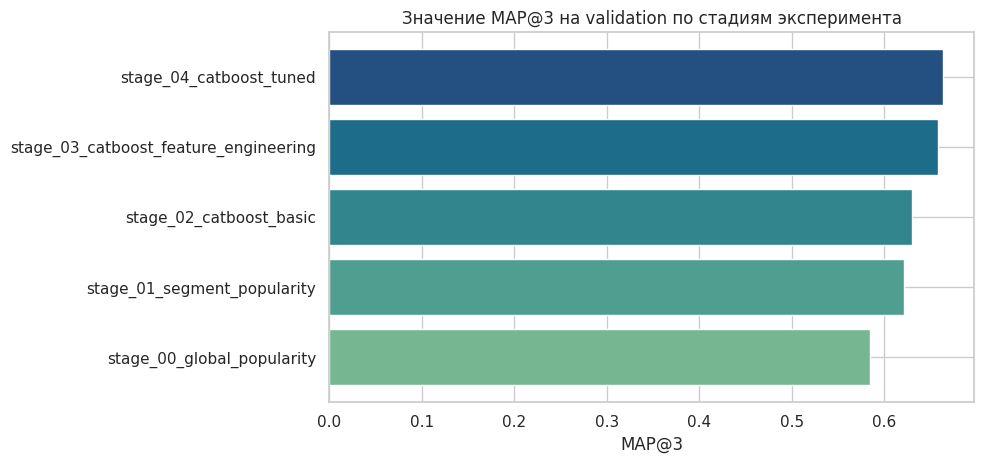

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = experiment_leaderboard.sort_values('val_map_at_3', ascending=True)
ax.barh(plot_df['stage_name'], plot_df['val_map_at_3'], color=sns.color_palette('crest', n_colors=len(plot_df)))
ax.set_title('Значение MAP@3 на validation по стадиям эксперимента')
ax.set_xlabel('MAP@3')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

На графике хорошо видна траектория улучшений. Глобальный baseline стартует с `val_map_at_3 = 0.5849`, сегментный baseline поднимается до `0.6215`, базовый CatBoost — до `0.6302`, CatBoost с feature engineering — до `0.6586`, а финальный tuned CatBoost достигает `0.6641`. То есть основной прирост приходит сначала от перехода к более сильной модели, а затем от feature engineering и аккуратного отбора конфигурации.


Новая tuning-stage важна тем, что позволяет проверять кандидаты последовательно и прозрачно. В этом прогоне Stage A проверил `4` конфигурации, а в Stage B были подтверждены только `2` лучших кандидата. Этого оказалось достаточно, чтобы выбрать устойчивого победителя без избыточного перебора.


## 9. Что произошло на новой tuning-stage

Ниже отдельно показаны результаты двух этапов подбора.

- `Stage A` отвечает за дешёвый screening и быстро отбрасывает слабые конфигурации.
- `Stage B` нужен не для нового перебора, а для честного подтверждения только лучших кандидатов в более полном режиме.

In [14]:
stage_a_leaderboard

,candidate_id,candidate_name,search_stage,run_id,fit_rows,eval_rows,fit_seconds,val_map_at_3,val_precision_at_3,val_recall_at_3,...,depth,learning_rate,l2_leaf_reg,min_data_in_leaf,random_strength,rsm,bootstrap_type,bagging_temperature,subsample,screening_rank
0,2,stage_04a_candidate_02,stage_a,d6e2ad00206c487eb2859563e09c3f9a,180000,120000,86.2200,0.6731,0.1635,0.7921,...,6,0.0600,5.0000,48,0.8000,0.8000,Bayesian,0.3000,NaN,1
1,3,stage_04a_candidate_03,stage_a,4c9751c7bf764132a024b35ff651e259,180000,120000,94.3100,0.6692,0.1627,0.7873,...,6,0.0500,6.0000,64,1.0000,0.7500,Bernoulli,NaN,0.8000,2
2,1,stage_04a_candidate_01,stage_a,1c91b7b5ed2046f0a34b25c21b848284,180000,120000,74.4000,0.6612,0.1620,0.7838,...,5,0.0700,4.0000,64,0.4000,0.8500,Bayesian,0.0000,NaN,3
3,4,stage_04a_candidate_04,stage_a,e421c1519b3348dcb512b0d45cea55c3,180000,120000,69.8400,0.6592,0.1609,0.7791,...,5,0.0900,7.0000,80,0.6000,0.9000,Bayesian,0.1000,NaN,4


Таблица Stage A показывает screening ручного search space. Лучший кандидат здесь — `stage_04a_candidate_02` с `val_map_at_3 = 0.6731`, `depth = 6`, `iterations = 180`, `learning_rate = 0.06`, `l2_leaf_reg = 5.0`, `min_data_in_leaf = 48`, `rsm = 0.8`. Вторым идёт `stage_04a_candidate_03` с `0.6692`. Разрыв между первым и последним кандидатом Stage A составляет примерно `0.0139` по `MAP@3`, так что screening действительно разделяет конфигурации по качеству.


In [15]:
stage_b_leaderboard

,candidate_id,candidate_name,search_stage,run_id,fit_rows,eval_rows,fit_seconds,val_map_at_3,val_precision_at_3,val_recall_at_3,...,iterations,depth,learning_rate,l2_leaf_reg,min_data_in_leaf,random_strength,rsm,bootstrap_type,bagging_temperature,subsample
0,3,stage_04b_candidate_03,stage_b,e126ae85ca7a4083ba6d57a14c1596ae,350000,360000,192.8400,0.6641,0.0809,0.7640,...,220,6,0.0500,6.0000,64,1.0000,0.7500,Bernoulli,NaN,0.8000
1,2,stage_04b_candidate_02,stage_b,2e3020feb62742cba05a9bd3e8818450,350000,360000,174.5200,0.6571,0.0809,0.7642,...,180,6,0.0600,5.0000,48,0.8000,0.8000,Bayesian,0.3000,NaN


Stage B подтверждает результат Stage A на более полном train sample. Победителем становится `stage_04b_candidate_03` с `val_map_at_3 = 0.6641`, `test_map_at_3 = 0.6527`, `iterations = 220`, `depth = 6`, `learning_rate = 0.05`, `l2_leaf_reg = 6.0`, `min_data_in_leaf = 64`, `bootstrap_type = Bernoulli`, `subsample = 0.8`. Второй кандидат Stage B (`stage_04b_candidate_02`) набирает `0.6571`, поэтому финальный выбор выглядит достаточно уверенным.


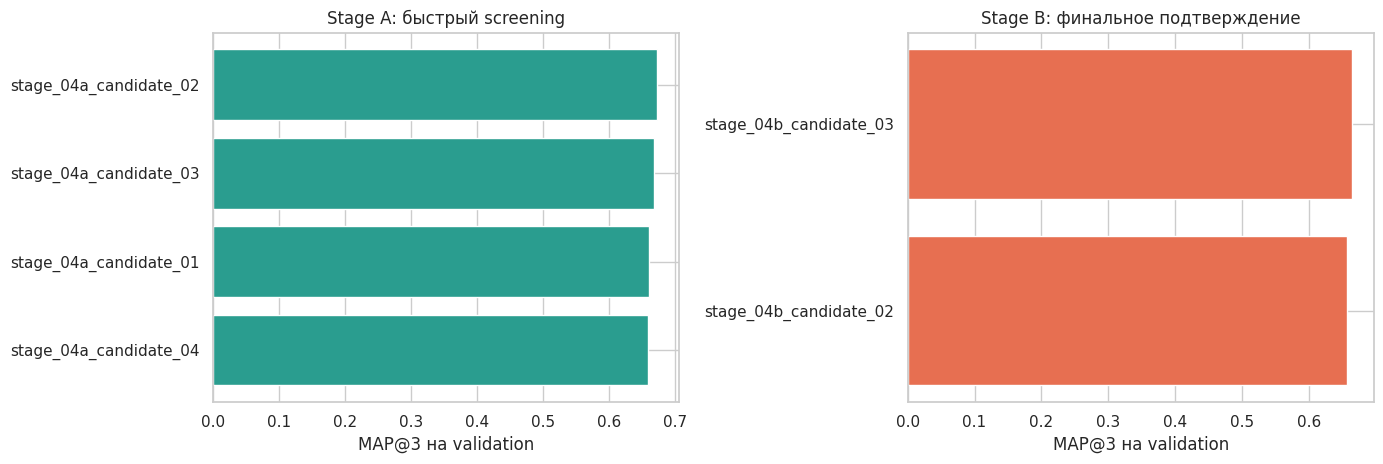

In [16]:
if not stage_a_leaderboard.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)

    stage_a_sorted = stage_a_leaderboard.sort_values('val_map_at_3', ascending=True)
    axes[0].barh(stage_a_sorted['candidate_name'], stage_a_sorted['val_map_at_3'], color='#2a9d8f')
    axes[0].set_title('Stage A: быстрый screening')
    axes[0].set_xlabel('MAP@3 на validation')
    axes[0].set_ylabel('')

    if not stage_b_leaderboard.empty:
        stage_b_sorted = stage_b_leaderboard.sort_values('val_map_at_3', ascending=True)
        axes[1].barh(stage_b_sorted['candidate_name'], stage_b_sorted['val_map_at_3'], color='#e76f51')
        axes[1].set_title('Stage B: финальное подтверждение')
        axes[1].set_xlabel('MAP@3 на validation')
        axes[1].set_ylabel('')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Парные графики читаются совместно. На Stage A лучший результат даёт `candidate_02`, но после подтверждения на полном train sample лидером становится `candidate_03`. Это важный результат: компактный screening хорошо отсекает слабые варианты, а финальное решение всё равно принимается на более строгом полном прогоне. Такая схема снижает риск выбрать конфигурацию только по «быстрому» этапу.


Интерпретация этой части проста:

- если Stage A уже хорошо отделяет сильные конфигурации от слабых, значит screening действительно выполняет свою роль;
- если победитель Stage B совпадает с лидером или почти лидером Stage A, значит схема устойчива и не зависит от случайного шума;
- если лидер меняется, Stage B показывает, зачем нужен второй шаг на полном train sample.

## 10. Feature importance и интерпретация модели

Ниже агрегируются важности признаков по продуктовым one-vs-rest моделям. Такая агрегация показывает признаки, которые стабильно влияют на вероятность нового подключения сразу в нескольких продуктовых задачах.


In [17]:
best_bundle = joblib.load(MODELS_DIR / 'best_model.joblib')
selected_stage = best_bundle['selected_model']
feature_importance = pd.read_csv(MODELS_DIR / f'{selected_stage}_feature_importance.csv')

aggregated_importance = (
    feature_importance.groupby('feature_name', as_index=False)
    .agg(mean_importance=('importance', 'mean'), covered_products=('product', 'nunique'))
    .sort_values('mean_importance', ascending=False)
)
aggregated_importance.head(15)

,feature_name,mean_importance,covered_products
0,age,10.9435,22
1,antiguedad,10.9088,22
31,month_number,10.3339,23
3,cod_prov,7.3768,13
36,products_dropped_prev_month,6.8179,21
8,ind_actividad_cliente,6.3625,20
9,ind_cco_fin_ult1,6.2008,15
6,customer_since_months,5.9077,23
10,ind_cno_fin_ult1,5.7651,17
41,tiprel_1mes,5.5604,20


Таблица aggregated importance показывает, что у модели есть несколько действительно доминирующих факторов. Топ-3 признака по средней важности — `age` (`10.94`), `antiguedad` (`10.91`) и `month_number` (`10.33`). При этом `month_number` и `customer_since_months` покрывают `23` продуктовые модели, а `age` и `antiguedad` — по `22`, то есть это не локальные сигналы одного продукта, а общая логика ранжирования.


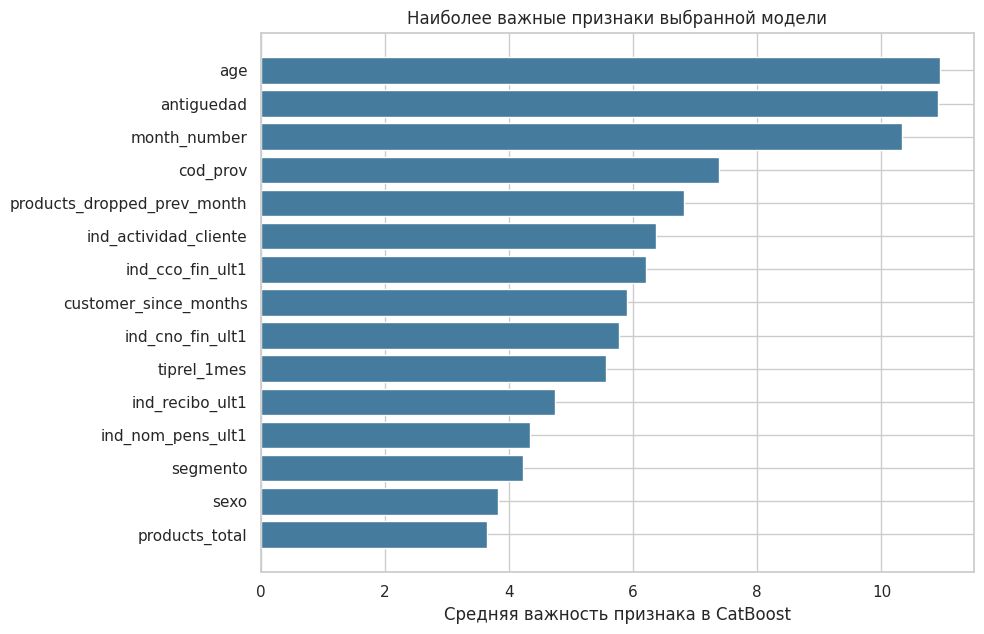

In [18]:
fig, ax = plt.subplots(figsize=(10, 6.5))
plot_importance = aggregated_importance.head(15).sort_values('mean_importance', ascending=True)
ax.barh(plot_importance['feature_name'], plot_importance['mean_importance'], color='#457b9d')
ax.set_title('Наиболее важные признаки выбранной модели')
ax.set_xlabel('Средняя важность признака в CatBoost')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

График показывает доминирующие сигналы модели. В верхней части обычно оказываются признаки, связанные с текущим портфелем, его недавней динамикой и базовым клиентским контекстом. Вероятность нового подключения определяется сочетанием состояния клиента и недавних изменений его продуктовой истории, а не одним статическим атрибутом.


Среди наиболее значимых признаков в текущем прогоне выделяются две группы.

- клиентский контекст: `age`, `antiguedad`, `cod_prov`, `ind_actividad_cliente`, `segmento`;
- поведение портфеля и его динамика: `month_number`, `products_dropped_prev_month`, `customer_since_months`, `ind_cco_fin_ult1`.

Это хорошо согласуется с постановкой задачи: модель использует и зрелость клиента, и недавние изменения в портфеле, чтобы предсказать наиболее вероятный следующий продукт.


## 11. Анализ качества по продуктам

Общая `MAP@3` используется для выбора модели, а таблица ниже показывает качество в разрезе продуктов. Для каждого продукта считается, как часто модель попадала в top-3 там, где этот продукт действительно появился.


In [19]:
test_frames = load_sampled_evaluation_frames(
    config,
    config.test_months,
    feature_columns=best_bundle['feature_columns'],
    sample_size=min(config.eval_month_sample_size, 20000),
    seed=config.random_state + 777,
)
test_df = pd.concat([frame for _, frame in test_frames], ignore_index=True)
scores = score_dataframe(best_bundle, test_df)
recommendations = build_recommendation_indices(scores, test_df[PRODUCT_COLUMNS].to_numpy(), k=config.top_k)
y_true = test_df[[f'target__{product}' for product in PRODUCT_COLUMNS]].to_numpy()

product_rows = []
for product_idx, product in enumerate(PRODUCT_COLUMNS):
    product_events = int(y_true[:, product_idx].sum())
    product_hits = int(sum(int(product_idx in row[:config.top_k]) and y_true[row_idx, product_idx] == 1 for row_idx, row in enumerate(recommendations)))
    recommended_count = int((recommendations[:, :config.top_k] == product_idx).sum())
    product_rows.append(
        {
            'product_code': product,
            'product_name': PRODUCT_NAME_MAP[product],
            'true_events': product_events,
            'top3_hits': product_hits,
            'hit_rate_at_3': product_hits / product_events if product_events else 0.0,
            'recommended_count': recommended_count,
        }
    )

product_quality = pd.DataFrame(product_rows).sort_values(['hit_rate_at_3', 'true_events'], ascending=[False, False])
product_quality.head(12)


,product_code,product_name,true_events,top3_hits,hit_rate_at_3,recommended_count
5,ind_ctju_fin_ult1,Junior account,26,26,1.0000,77
2,ind_cco_fin_ult1,Current accounts,2938,2691,0.9159,8533
6,ind_ctma_fin_ult1,More particular account,417,381,0.9137,8085
11,ind_dela_fin_ult1,Long-term deposits,67,51,0.7612,5577
21,ind_nomina_ult1,Payroll,3398,2576,0.7581,6360
23,ind_recibo_ult1,Direct debit,7307,5368,0.7346,10208
22,ind_nom_pens_ult1,Pensions payroll,3633,2657,0.7314,5360
4,ind_cno_fin_ult1,Payroll account,1699,1195,0.7034,5255
12,ind_ecue_fin_ult1,E-account,1804,1253,0.6946,7189
18,ind_tjcr_fin_ult1,Credit card,3038,1920,0.6320,5270


Эта таблица показывает качество модели в разрезе продуктов. Лучше всего в sampled test подхватываются `ind_ctju_fin_ult1` (`hit_rate@3 = 1.0000`, но всего `26` событий), `ind_cco_fin_ult1` (`0.9159` при `2,938` событиях) и `ind_ctma_fin_ult1` (`0.9137` при `417` событиях). Среди самых массовых продуктов сильный результат также показывают `Payroll` (`0.7581` при `3,398` событиях), `Direct debit` (`0.7346` при `7,307`) и `Pensions payroll` (`0.7314` при `3,633`).


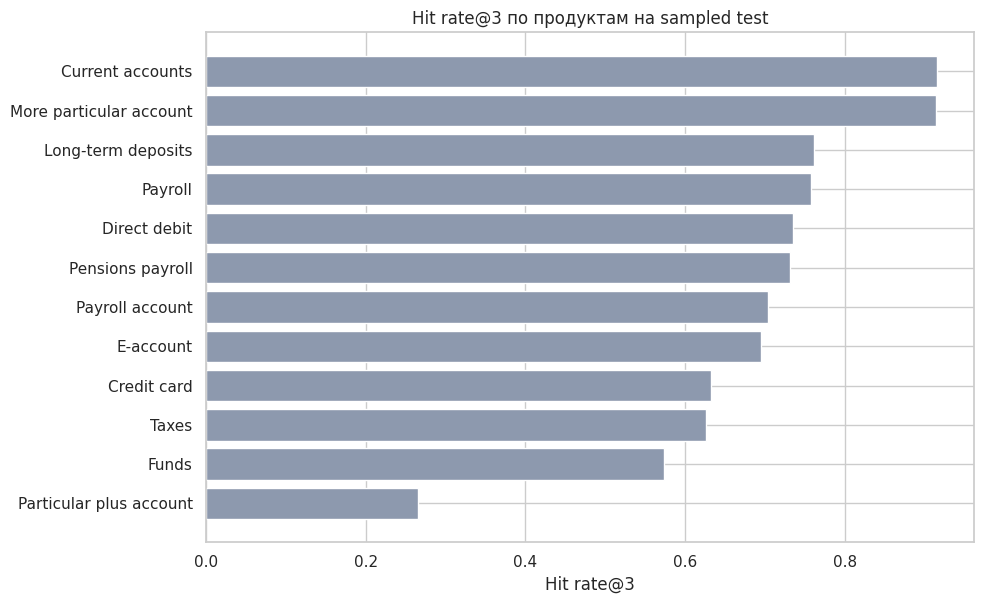

In [20]:
plot_product_quality = product_quality.loc[product_quality['true_events'] >= 30].head(12).sort_values('hit_rate_at_3', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.2))
ax.barh(plot_product_quality['product_name'], plot_product_quality['hit_rate_at_3'], color='#8d99ae')
ax.set_title('Hit rate@3 по продуктам на sampled test')
ax.set_xlabel('Hit rate@3')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

На графике различия между продуктами становятся визуально очевидными. Более массовые продукты обычно имеют более высокий hit rate@3, потому что по ним в данных сильнее обучающий сигнал. Продукты с низким hit rate часто оказываются либо редкими, либо более сложными для предсказания, и именно они формируют основную зону дальнейших улучшений модели.


Per-product разрез показывает три свойства.

- массовые продукты действительно дают основной вклад в итоговый quality: например, `Direct debit`, `Payroll`, `Pensions payroll`, `Current accounts`;
- редкие продукты могут иметь очень высокий `hit_rate@3`, но такие значения нужно интерпретировать осторожно из-за малого числа событий, как в случае `Junior account`;
- более сложными остаются продукты вроде `Credit card` (`0.6320` при `3,038` событиях) и `Taxes` (`0.6257` при `374` событиях), где модель заметно чаще ошибается.


## 12. Распределение score и error analysis

Раздел ниже показывает две стороны поведения модели:

- распределение top-score в ранжировании;
- реальные случаи ошибок на уровне клиентов и продуктов.


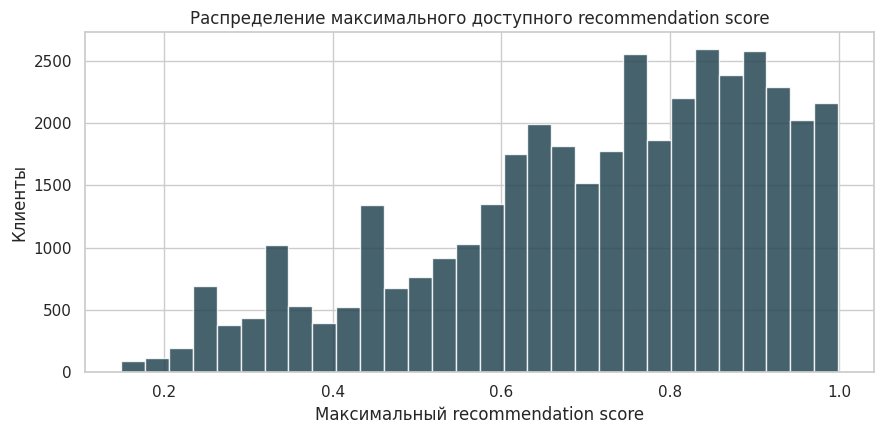

In [21]:
masked_scores = scores.copy()
masked_scores[test_df[PRODUCT_COLUMNS].to_numpy() == 1] = -1.0
top_scores = np.max(masked_scores, axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(top_scores[top_scores > -1], bins=30, color='#264653', alpha=0.85)
ax.set_title('Распределение максимального доступного recommendation score')
ax.set_xlabel('Максимальный recommendation score')
ax.set_ylabel('Клиенты')
plt.tight_layout()
plt.show()

Распределение top-score показывает, что модель не сводится к случайному выбору: для заметной доли клиентов она выделяет ограниченный набор более сильных кандидатов. Это согласуется и с общей метрикой `MAP@3 = 0.6641` на validation, и с per-product quality по наиболее массовым продуктам.


In [22]:
validation_errors_path = MODELS_DIR / f'{selected_stage}_validation_errors.csv'
validation_errors = pd.read_csv(validation_errors_path) if validation_errors_path.exists() else pd.DataFrame()
validation_errors.head(10)

,fecha_dato,target_month,ncodpers,segmento,products_total,true_products,recommended_products,missed_products,split_name,snapshot_month
0,2015-12-28 00:00:00,2016-01-28 00:00:00,453402,02 - PARTICULARES,2.0000,['ind_reca_fin_ult1'],"['ind_recibo_ult1', 'ind_plan_fin_ult1', 'ind_dela_fin_ult1']",['ind_reca_fin_ult1'],valid,2015-12-28
1,2015-12-28 00:00:00,2016-01-28 00:00:00,123500,02 - PARTICULARES,2.0000,"['ind_dela_fin_ult1', 'ind_recibo_ult1']","['ind_dela_fin_ult1', 'ind_plan_fin_ult1', 'ind_cno_fin_ult1']",['ind_recibo_ult1'],valid,2015-12-28
2,2015-12-28 00:00:00,2016-01-28 00:00:00,822807,02 - PARTICULARES,1.0000,['ind_recibo_ult1'],"['ind_ctpp_fin_ult1', 'ind_reca_fin_ult1', 'ind_plan_fin_ult1']",['ind_recibo_ult1'],valid,2015-12-28
3,2015-12-28 00:00:00,2016-01-28 00:00:00,945433,02 - PARTICULARES,1.0000,['ind_cco_fin_ult1'],"['ind_ecue_fin_ult1', 'ind_nomina_ult1', 'ind_cno_fin_ult1']",['ind_cco_fin_ult1'],valid,2015-12-28
4,2015-12-28 00:00:00,2016-01-28 00:00:00,909438,03 - UNIVERSITARIO,1.0000,['ind_recibo_ult1'],"['ind_cco_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1']",['ind_recibo_ult1'],valid,2015-12-28
5,2015-12-28 00:00:00,2016-01-28 00:00:00,624276,02 - PARTICULARES,2.0000,['ind_ecue_fin_ult1'],"['ind_dela_fin_ult1', 'ind_valo_fin_ult1', 'ind_ctop_fin_ult1']",['ind_ecue_fin_ult1'],valid,2015-12-28
6,2015-12-28 00:00:00,2016-01-28 00:00:00,283869,01 - TOP,4.0000,['ind_tjcr_fin_ult1'],"['ind_cno_fin_ult1', 'ind_plan_fin_ult1', 'ind_dela_fin_ult1']",['ind_tjcr_fin_ult1'],valid,2015-12-28
7,2015-12-28 00:00:00,2016-01-28 00:00:00,172102,02 - PARTICULARES,3.0000,"['ind_ctop_fin_ult1', 'ind_recibo_ult1']","['ind_recibo_ult1', 'ind_ecue_fin_ult1', 'ind_plan_fin_ult1']",['ind_ctop_fin_ult1'],valid,2015-12-28
8,2015-12-28 00:00:00,2016-01-28 00:00:00,207838,01 - TOP,1.0000,['ind_valo_fin_ult1'],"['ind_dela_fin_ult1', 'ind_fond_fin_ult1', 'ind_ecue_fin_ult1']",['ind_valo_fin_ult1'],valid,2015-12-28
9,2015-12-28 00:00:00,2016-01-28 00:00:00,519997,02 - PARTICULARES,4.0000,['ind_tjcr_fin_ult1'],"['ind_plan_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1']",['ind_tjcr_fin_ult1'],valid,2015-12-28


## 13. Связь с MLflow и итоговый выбор модели

Новая схема отбора специально синхронизирована с MLflow:

- каждый tuning-кандидат логируется как отдельный run;
- у всех runs используется единая главная метрика `val_map_at_3`;
- финальная tuned-модель отдельно сохраняется как полноценный stage-run;
- выбранный CatBoost-run регистрируется в MLflow Model Registry.


По таблице ошибок можно отдельно смотреть конкретные типы промахов. В сохранённом validation error set `90` строк, и чаще всего в `missed_products` встречаются `ind_tjcr_fin_ult1` (`20` раз), `ind_recibo_ult1` (`19`), `ind_nom_pens_ult1` (`13`) и `ind_ecue_fin_ult1` (`12`). Это означает, что основная зона улучшения связана не с редкими экзотическими продуктами, а с несколькими важными направлениями, которые модель иногда не поднимает в top-3.


In [23]:
selected_stage = metadata['selected_model']
selected_stage_payload = metadata['stages'][selected_stage]

pd.DataFrame(
    {
        'selected_stage': [selected_stage],
        'primary_metric_name': [metadata['primary_metric_name']],
        'validation_metric_value': [selected_stage_payload['valid'][f'map_at_{config.top_k}']],
        'registered_model_name': [metadata['registered_model_name']],
        'registry_alias': [metadata['registered_model_alias']],
        'registry_version': [selected_stage_payload.get('registry_version')],
        'run_id': [selected_stage_payload.get('run_id')],
    }
)


,selected_stage,primary_metric_name,validation_metric_value,registered_model_name,registry_alias,registry_version,run_id
0,stage_04_catboost_tuned,val_map_at_3,0.6641,bank-product-recommendations-catboost,champion,5,84f4cd55105a4ca8a669a5bc224fd6fc


Финальная таблица фиксирует связь между экспериментом и production-артефактом. Победителем выбран `stage_04_catboost_tuned`, главная метрика — `val_map_at_3`, значение на validation равно `0.6641`, run id — `84f4cd55105a4ca8a669a5bc224fd6fc`, а зарегистрированная версия модели в MLflow Model Registry — `5` с alias `champion`.


## 14. Вывод


Итоговая картина проекта по этому прогону получилась достаточно сильной и цельной. Задача корректно поставлена как recommendation / ranking по новым продуктам следующего месяца, а итоговая модель — `stage_04_catboost_tuned` — показывает `val_map_at_3 = 0.6641` и `test_map_at_3 = 0.6527`. Это лучший результат среди всех рассмотренных стадий.

Траектория улучшений читается последовательно: глобальный baseline даёт `0.5849`, сегментный baseline — `0.6215`, базовый CatBoost — `0.6302`, CatBoost с feature engineering — `0.6586`, а tuned CatBoost добавляет ещё `+0.0054` к validation `MAP@3` и `+0.0021` к test `MAP@3` относительно `stage_03`. То есть основная модель не просто победила формально, а закрепила выигрыш и на holdout-периоде.

Дополнительный плюс текущего результата — хорошая интерпретируемость. Модель в основном опирается на возраст, стаж клиента, календарный месяц, динамику портфеля и признаки текущей активности. При этом лучшие per-product результаты достигаются не только на редких продуктах, но и на крупных массовых категориях вроде `Current accounts`, `Payroll`, `Direct debit` и `Pensions payroll`, что делает итог более убедительным для практического recommendation-сценария.
